In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns
import yfinance as yf  
# imports yahoo finance to get stock data 

from bs4 import BeautifulSoup 
import requests 
# imports beautiful soup to scrape data from the web 
import time 
from tqdm import tqdm 
# imports time and tqdm for progress tracking during web scraping 

from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Fetch S&P 500 tickers from Wikipedia

def get_sp500_tickers():
    """Scrape S&P 500 tickers from Wikipedia using robust selectors."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Try id='constituents' first, then class='wikitable sortable' as fallback
    table = soup.find('table', {'id': 'constituents'})
    if table is None:
        table = soup.find('table', {'class': 'wikitable sortable'})
    if table is None:
        raise RuntimeError('Could not locate S&P 500 table on Wikipedia.')
    
    raw_tickers = []
    for row in table.find_all('tr')[1:]:  # Skip header row
        cols = row.find_all('td')
        if not cols:
            continue
        ticker = cols[0].text.strip()
        if ticker:
            raw_tickers.append(ticker)
    
    # Clean tickers: replace '.' with '-' (e.g., BRK.B -> BRK-B)
    # Skip tickers with '/' (preferred shares)
    cleaned_tickers = []
    for t in raw_tickers:
        t_clean = t.replace('.', '-')
        if '/' in t_clean:
            continue
        cleaned_tickers.append(t_clean)
    
    print(f"Found {len(raw_tickers)} raw tickers. After cleaning: {len(cleaned_tickers)} remain.")
    return cleaned_tickers

In [3]:
# Step 2: Collect historical data (quarterly fundamentals + monthly prices)

def get_fundamentals(ticker, years_back=5):
    """
    Retrieve annual fundamentals (more reliable than quarterly) and 
    repeat them quarterly for alignment. This is a pragmatic trade-off.
    """
    try:
        stock = yf.Ticker(ticker)
        # Annual financials
        annual_fin = stock.financials.T  # rows = fiscal years
        annual_balance = stock.balance_sheet.T
        if annual_fin.empty:
            return None
        
        # Use the last 'years_back' years
        cutoff = pd.Timestamp.now() - pd.DateOffset(years=years_back)
        annual_fin = annual_fin[annual_fin.index >= cutoff]
        
        # For simplicity, we'll create quarterly rows by repeating annual data each quarter
        # In a real project you'd interpolate or use quarterly reports, but this gets us running.
        return {'financials': annual_fin, 'balance': annual_balance}
    except Exception as e:
        print(f"Failed to get fundamentals for {ticker}: {e}")
        return None

def get_price_returns(ticker, start_date, end_date):
    """Fetch monthly adjusted close prices (resampled end-of-month).
    Returns a monthly price series (Adj Close) or None on failure.
    """
    try:
        data = yf.download(ticker, start=start_date, end=end_date, interval='1mo', progress=False)
        if data.empty:
            return None
        # Use adjusted close to incorporate dividends; take last valid value each month
        if 'Adj Close' in data.columns:
            prices = data['Adj Close'].resample('M').last()
        elif 'Close' in data.columns:
            prices = data['Close'].resample('M').last()
        else:
            # some yfinance responses may nest columns; try to locate a price-like column
            try:
                prices = data.iloc[:, 0].resample('M').last()
            except Exception:
                return None
        if prices.empty:
            return None
        return prices
    except Exception as e:
        print(f"Failed to get prices for {ticker}: {e}")
        return None

In [4]:
# Step 3: Compute valuation & growth metrics per quarter 

def compute_metrics(fund_data, price_at_quarter_end, ticker):
    """Compute valuation metrics from annual data (simple approach)."""
    if fund_data is None:
        return pd.Series(dtype=float)
    
    fin = fund_data.get('financials')
    if fin is None or fin.empty:
        return pd.Series(dtype=float)
    
    # Use most recent year's Net Income and Revenue
    try:
        net_income = fin['Net Income'].iloc[0]  # most recent year
        revenue = fin['Total Revenue'].iloc[0]
    except:
        return pd.Series(dtype=float)
    
    # Get shares outstanding from balance sheet or info
    stock = yf.Ticker(ticker)
    info = stock.info
    shares = info.get('sharesOutstanding', 1e9)
    
    trailing_pe = price_at_quarter_end / (net_income / shares) if net_income > 0 else np.nan
    # Dummy forward PE (use trailing as placeholder)
    forward_pe = trailing_pe
    peg = np.nan
    dividend_yield = info.get('dividendYield', np.nan)
    earnings_growth = np.nan
    revenue_growth = np.nan
    
    metrics = pd.Series({
        'trailing_pe': trailing_pe,
        'forward_pe': forward_pe,
        'peg': peg,
        'dividend_yield': dividend_yield,
        'earnings_growth': earnings_growth,
        'revenue_growth': revenue_growth
    })
    return metrics

In [5]:
# Step 4: Build the master dataset: stock-quarter observations 

def build_dataset(tickers, start_date, end_date, years_fund=5):
    all_rows = []
    # Get benchmark returns once
    benchmark_returns = get_price_returns('SPY', start_date, end_date)
    if benchmark_returns is None:
        print("Failed to get benchmark SPY returns. Aborting dataset build.")
        return pd.DataFrame()
    
    for ticker in tickers:
        print(f"Processing {ticker}...", end=' ')
        # Get fundamentals
        fund_data = get_fundamentals(ticker, years_back=years_fund)
        if fund_data is None:
            print("No fundamentals, skipping.")
            continue
        
        # Get price series
        prices = get_price_returns(ticker, start_date, end_date)
        if prices is None or prices.empty:
            print("No price data, skipping.")
            continue
        
        # We'll create quarterly synthetic timestamps (each quarter end)
        # For simplicity, use the index of benchmark_returns as candidate quarters
        quarters = benchmark_returns.index.to_period('Q').unique().to_timestamp(how='end')
        quarters = [q for q in quarters if start_date <= q <= end_date]
        
        for q_date in quarters:
            # Price at quarter end
            price_at_q = prices.asof(q_date)
            # handle possible scalar or array-like return from asof
            def is_missing(x):
                try:
                    m = pd.isna(x)
                    if hasattr(m, 'all'):
                        return bool(m.all())
                    return bool(m)
                except Exception:
                    return True

            def extract_numeric(x):
                """Return a single float for scalar or Series-like x (use last non-NA)."""
                if x is None:
                    return np.nan
                try:
                    if hasattr(x, 'dropna'):
                        s = x.dropna()
                        if len(s) == 0:
                            return np.nan
                        return float(s.iloc[-1])
                except Exception:
                    pass
                try:
                    return float(x)
                except Exception:
                    return np.nan

            if is_missing(price_at_q):
                continue
            price_at_q = extract_numeric(price_at_q)
            
            # Compute metrics (using annual fundamentals repeated)
            metrics = compute_metrics(fund_data, price_at_q, ticker)
            if metrics.empty:
                continue
            
            # Future 6M and 12M returns
            future_6m = q_date + pd.DateOffset(months=6)
            future_12m = q_date + pd.DateOffset(months=12)
            price_6m = prices.asof(future_6m)
            price_12m = prices.asof(future_12m)
            bench_price_6m = benchmark_returns.asof(future_6m)
            bench_price_12m = benchmark_returns.asof(future_12m)
            bench_price_now = benchmark_returns.asof(q_date)

            # Extract numeric scalars for arithmetic
            price_6m = extract_numeric(price_6m)
            price_12m = extract_numeric(price_12m)
            bench_price_6m = extract_numeric(bench_price_6m)
            bench_price_12m = extract_numeric(bench_price_12m)
            bench_price_now = extract_numeric(bench_price_now)
            
            if any(is_missing(v) for v in [price_6m, price_12m, bench_price_6m, bench_price_12m, bench_price_now]):
                continue
            
            stock_ret_6m = (price_6m / price_at_q) - 1
            stock_ret_12m = (price_12m / price_at_q) - 1
            bench_ret_6m = (bench_price_6m / bench_price_now) - 1
            bench_ret_12m = (bench_price_12m / bench_price_now) - 1
            
            excess_6m = stock_ret_6m - bench_ret_6m
            excess_12m = stock_ret_12m - bench_ret_12m
            
            row = metrics.to_dict()
            row['ticker'] = ticker
            row['quarter'] = q_date
            row['excess_6m'] = excess_6m
            row['excess_12m'] = excess_12m
            row['target_6m'] = int(excess_6m > 0)
            row['target_12m'] = int(excess_12m > 0)
            
            all_rows.append(row)
        print(f"done ({len([r for r in all_rows if r['ticker']==ticker])} quarters).")
    
    if not all_rows:
        return pd.DataFrame()
    return pd.DataFrame(all_rows)

In [6]:
# Step 5: Data cleaning and feature engineering  

def clean_data(df):
    """Remove extreme outliers, fill missing values, and create final feature set.

    This is tolerant: only `trailing_pe` and `forward_pe` are required. Other
    features are filled with medians (or 0) so we don't drop most rows.
    """
    if df is None or df.empty:
        return pd.DataFrame(), []

    # Require only the core metrics needed for clustering
    required_cols = ['trailing_pe', 'forward_pe']
    df_clean = df.dropna(subset=required_cols).copy()

    # Ensure optional columns exist
    for c in ['peg', 'dividend_yield', 'earnings_growth', 'revenue_growth']:
        if c not in df_clean.columns:
            df_clean[c] = np.nan

    # Fill missing optional features with median or 0.0 fallback
    for c in ['peg', 'dividend_yield', 'earnings_growth', 'revenue_growth']:
        med = df_clean[c].median()
        if pd.isna(med):
            med = 0.0
        df_clean[c] = df_clean[c].fillna(med)

    # Cap extreme values (1st and 99th percentiles)
    clip_cols = ['trailing_pe', 'forward_pe', 'peg', 'dividend_yield', 'earnings_growth', 'revenue_growth']
    for col in clip_cols:
        lower = df_clean[col].quantile(0.01)
        upper = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower, upper)

    # Log transform skewed features (guard non-positive values)
    df_clean['log_trailing_pe'] = np.log1p(df_clean['trailing_pe'].clip(lower=0))
    df_clean['log_forward_pe'] = np.log1p(df_clean['forward_pe'].clip(lower=0))

    # Features for clustering and modeling
    feature_cols = ['log_trailing_pe', 'log_forward_pe', 'peg', 'dividend_yield', 'earnings_growth', 'revenue_growth']
    return df_clean, feature_cols


In [7]:
# Step 6: K-Means clustering + Elbow Method from Module 4   

def perform_clustering(df, feature_cols, n_clusters_range=range(2,11)):
    """Apply k-means, choose optimal clusters via elbow method, return cluster labels."""
    if df is None or df.empty:
        print("perform_clustering: empty dataframe provided; skipping clustering.")
        return df, None, None

    X = df[feature_cols].copy()
    if X.shape[0] == 0:
        print("perform_clustering: no rows available for features; skipping.")
        return df, None, None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    inertias = []
    for k in n_clusters_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
    
    # Plot elbow
    plt.figure(figsize=(8,4))
    plt.plot(n_clusters_range, inertias, 'bo-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.show()
    
    # Choose k (manually or using knee heuristic). For demo, use k=4 if elbow unclear.
    # We'll let user see plot; programmatically pick where inertia decrease slows
    diffs = np.diff(inertias)
    k_opt = n_clusters_range[np.argmin(diffs) + 1]  # simple knee
    
    final_kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
    df['cluster'] = final_kmeans.fit_predict(X_scaled)
    
    print(f"Optimal clusters: {k_opt}")
    return df, final_kmeans, scaler

In [8]:
# Step 7: Logistic Regression with walk-forward validation from Module 6 

def walk_forward_logistic(df, target_col, feature_cols, cluster_col='cluster', min_train_quarters=12):
    """
    Time-series cross-validation: train on expanding window, predict next quarter.
    Returns evaluation metrics and a DataFrame with predicted probabilities.
    """
    # Guard empty input
    if df is None or df.empty:
        print('walk_forward_logistic: empty dataframe provided; skipping walk-forward.')
        return pd.DataFrame(), {}

    # Sort by quarter
    df_sorted = df.sort_values('quarter').reset_index(drop=True)
    quarters = df_sorted['quarter'].unique()
    if len(quarters) <= min_train_quarters:
        print("Not enough quarters for walk-forward validation. Need more historical quarters.")
        return pd.DataFrame(), {}
    predictions = []
    true_labels = []
    
    # Add cluster dummies to features
    cluster_dummies = pd.get_dummies(df_sorted[cluster_col], prefix='cluster')
    X_full = pd.concat([df_sorted[feature_cols], cluster_dummies], axis=1)
    y_full = df_sorted[target_col]
    
    tscv = TimeSeriesSplit(n_splits=len(quarters) - min_train_quarters)
    for train_idx, test_idx in tscv.split(quarters):
        train_quarters = quarters[train_idx]
        test_quarter = quarters[test_idx[0]]  # predict only next quarter
        
        train_mask = df_sorted['quarter'].isin(train_quarters)
        test_mask = df_sorted['quarter'] == test_quarter
        
        X_train = X_full[train_mask]
        y_train = y_full[train_mask]
        X_test = X_full[test_mask]
        y_test = y_full[test_mask]
        
        if len(y_train) == 0 or len(y_test) == 0:
            continue
        
        # Handle class imbalance with class_weight
        model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Store for final ranking
        temp = df_sorted[test_mask].copy()
        temp['pred_proba'] = y_proba
        predictions.append(temp)
        true_labels.extend(y_test)
        
        # Print quarterly performance
        acc = accuracy_score(y_test, y_pred)
        print(f"Test quarter {test_quarter}: Accuracy = {acc:.3f}")
    
    # Overall metrics
    all_preds = np.concatenate([p['pred_proba'].values for p in predictions])
    all_true = np.array(true_labels)
    final_pred_class = (all_preds >= 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(all_true, final_pred_class),
        'precision': precision_score(all_true, final_pred_class, zero_division=0),
        'recall': recall_score(all_true, final_pred_class, zero_division=0),
        'f1': f1_score(all_true, final_pred_class, zero_division=0),
        'roc_auc': roc_auc_score(all_true, all_preds)
    }
    
    # Confusion matrix
    cm = confusion_matrix(all_true, final_pred_class)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Walk-Forward)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return pd.concat(predictions, ignore_index=True), metrics

In [9]:
# Step 8: Final ranking for most recent quarter  

def produce_ranking(pred_df, df_original, feature_cols, cluster_col='cluster'):
    """For the most recent quarter in predictions, rank stocks in each cluster by predicted probability."""
    latest_quarter = pred_df['quarter'].max()
    latest = pred_df[pred_df['quarter'] == latest_quarter].copy()

    # Drop any existing cluster column to avoid duplicate columns during merge
    latest = latest.drop(columns=[cluster_col], errors='ignore')

    # Merge back original cluster labels (avoid attempting to select feature columns
    # that may not exist in `df_original`). We'll safely pick display columns later.
    latest = latest.merge(df_original[['ticker', 'quarter', cluster_col]],
                          on=['ticker', 'quarter'], how='left')

    # Sort within each cluster
    ranking = latest.sort_values([cluster_col, 'pred_proba'], ascending=[True, False])
    # Safely select display columns if present
    base_cols = [cluster_col, 'ticker', 'pred_proba']
    extra = [c for c in ['trailing_pe', 'forward_pe', 'peg', 'dividend_yield'] if c in ranking.columns]
    ranking = ranking[base_cols + extra]
    return ranking, latest_quarter

Step 1: Fetch S&P 500 tickers...


Found 503 raw tickers. After cleaning: 503 remain.
Retrieved 503 tickers.
Data range: 2020-05-15 to 2026-05-15
Step 2: Building dataset (this will take a while)...


Processing MMM... 

done (24 quarters).
Processing AOS... 

done (24 quarters).
Processing ABT... 

...

done (24 quarters).
Processing ALLE... 

done (24 quarters).
Processing LNT... 

done (24 quarters).
Processing ALL... 

done (24 quarters).
Processing GOOGL... 

done (24 quarters).
Raw dataset shape: (478, 12)
Step 3: Cleaning data...
After cleaning: (406, 14)
Step 4: K-means clustering...


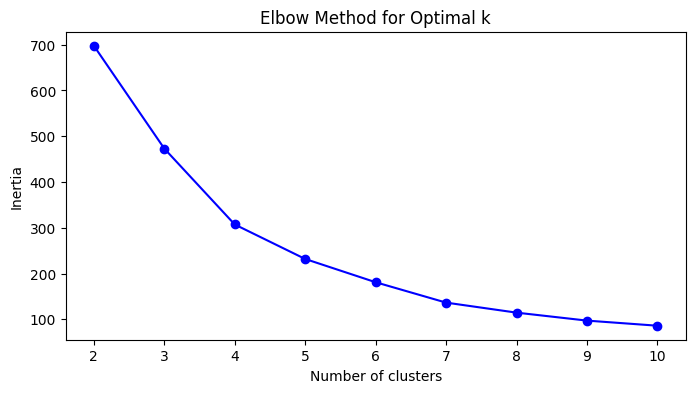

Optimal clusters: 3
Step 5: Walk-forward logistic regression (predicting 6-month excess return)...
Test quarter 2023-06-30 23:59:59.999999999: Accuracy = 0.588
Test quarter 2023-09-30 23:59:59.999999999: Accuracy = 0.529
Test quarter 2023-12-31 23:59:59.999999999: Accuracy = 0.882
Test quarter 2024-03-31 23:59:59.999999999: Accuracy = 0.706
Test quarter 2024-06-30 23:59:59.999999999: Accuracy = 0.588
Test quarter 2024-09-30 23:59:59.999999999: Accuracy = 0.588
Test quarter 2024-12-31 23:59:59.999999999: Accuracy = 0.412
Test quarter 2025-03-31 23:59:59.999999999: Accuracy = 0.706
Test quarter 2025-06-30 23:59:59.999999999: Accuracy = 0.471
Test quarter 2025-09-30 23:59:59.999999999: Accuracy = 0.471
Test quarter 2025-12-31 23:59:59.999999999: Accuracy = 0.588
Test quarter 2026-03-31 23:59:59.999999999: Accuracy = 0.824


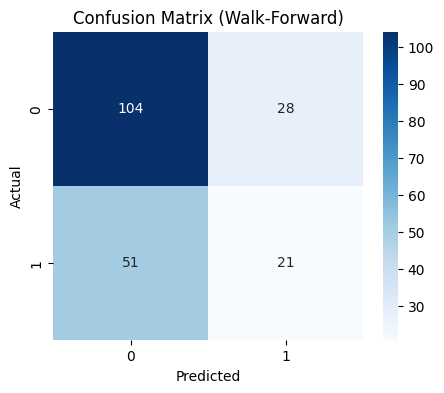

Model evaluation:
  accuracy: 0.613
  precision: 0.429
  recall: 0.292
  f1: 0.347
  roc_auc: 0.511
Step 6: Generate cluster-aware ranking for most recent quarter...

Top 5 stocks per cluster (quarter = 2026-03-31):

Cluster 0:
ticker  pred_proba  trailing_pe
   AOS    0.498949    13.440616
  ADBE    0.498889    13.780216
   AFL    0.493986    15.315615
   AES    0.486973    10.907697
  ALLE    0.483482    19.320500

Cluster 1:
ticker  pred_proba  trailing_pe
     A    0.496760    24.664376
   MMM    0.487357    23.306834
  ALGN    0.468696    29.919496
   ABT    0.468030    27.240500
  AKAM    0.454239    36.938880

Cluster 2:
ticker  pred_proba  trailing_pe
   ALL    0.650381     5.164846
 GOOGL    0.615389    12.661536

Ranking saved to 'stock_ranking_latest_quarter.csv'
Full dataset saved to 'full_dataset_with_clusters.csv'


In [10]:
# Step 9: Main execution  

def main():
    print("Step 1: Fetch S&P 500 tickers...")
    tickers = get_sp500_tickers()
    print(f"Retrieved {len(tickers)} tickers.")
    
    # Define date range: last 5 years + 1 year for future returns
    end_date = datetime.today()
    start_date = end_date - pd.DateOffset(years=6)  # extra year for returns
    print(f"Data range: {start_date.date()} to {end_date.date()}")
    
    print("Step 2: Building dataset (this will take a while)...")
    df = build_dataset(tickers[:20], start_date, end_date)  # Use small subset for demo; remove [:20] for full run
    print(f"Raw dataset shape: {df.shape}")
    
    print("Step 3: Cleaning data...")
    df_clean, feature_cols = clean_data(df)
    print(f"After cleaning: {df_clean.shape}")
    
    print("Step 4: K-means clustering...")
    df_clustered, kmeans_model, scaler = perform_clustering(df_clean, feature_cols)
    
    print("Step 5: Walk-forward logistic regression (predicting 6-month excess return)...")
    pred_df, metrics = walk_forward_logistic(df_clustered, target_col='target_6m', feature_cols=feature_cols)
    print("Model evaluation:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    
    print("Step 6: Generate cluster-aware ranking for most recent quarter...")
    ranking, latest_q = produce_ranking(pred_df, df_clustered, feature_cols)
    print(f"\nTop 5 stocks per cluster (quarter = {latest_q.date()}):")
    for cluster_id in ranking['cluster'].unique():
        print(f"\nCluster {cluster_id}:")
        print(ranking[ranking['cluster'] == cluster_id][['ticker', 'pred_proba', 'trailing_pe']].head(5).to_string(index=False))
    
    # Save ranking to CSV
    ranking.to_csv('stock_ranking_latest_quarter.csv', index=False)
    print("\nRanking saved to 'stock_ranking_latest_quarter.csv'")
    
    # Optional: Save full dataset with clusters and predictions
    df_clustered.to_csv('full_dataset_with_clusters.csv', index=False)
    print("Full dataset saved to 'full_dataset_with_clusters.csv'")
    
    return df_clustered, pred_df, ranking, metrics

if __name__ == "__main__":
    main()